# Experiment 4: Deduplication on Devign, testing on Juliet_C


In [4]:
import sys
sys.path.insert(0, '/Users/aeg00011/Romeo')

# Force reimport of preprocessing module to ensure latest changes are used
import importlib
if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']

# Import preprocessing module
from preprocessing import (
    preprocess_data
)

# Other required imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import AutoTokenizer
import os
import json
import datetime
import shutil

print("All imports successful!")
print(f"Experiment started at: {datetime.datetime.now().isoformat()}")

Preprocessing functions defined successfully!
All imports successful!
Experiment started at: 2026-02-04T15:24:19.457749


## 2. Initialize Tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/deepseek-coder-6.7b-base", trust_remote_code=True)
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {tokenizer.vocab_size}")
print("Loaded tokenizer size:", len(tokenizer))
print(f"Model max length: {tokenizer.model_max_length}")

Tokenizer loaded: LlamaTokenizerFast
Vocab size: 32000
Loaded tokenizer size: 32022
Model max length: 16384


In [7]:
# Define paths
BASE_DIR = '/Users/aeg00011/Romeo'
EXPERIMENT_DIR = os.path.join(BASE_DIR, 'tensors', 'Experiment_4')
SIMHASH_DIR = os.path.join(BASE_DIR, 'simhash_datasets')
DATASETS_DIR = os.path.join(BASE_DIR, 'datasets')

# Create Experiment directory
if os.path.exists(EXPERIMENT_DIR):
    print(f"Warning: {EXPERIMENT_DIR} already exists!")
    response = input("Delete existing directory and start fresh? (yes/no): ")
    if response.lower() == 'yes':
        shutil.rmtree(EXPERIMENT_DIR)
        print("Deleted existing directory.")
    else:
        print("Continuing with existing directory. Some files may be overwritten.")

os.makedirs(EXPERIMENT_DIR, exist_ok=True)
print(f"Experiment directory: {EXPERIMENT_DIR}")

# Verify simhash datasets exist
print(f"\nChecking simhash datasets...")
for k in range(1, 13):
    db_path = os.path.join(SIMHASH_DIR, f'devign_simhash_k={k}.db')
    exists = os.path.exists(db_path)
    status = "✓" if exists else "✗"
    print(f"  {status} k={k}: {os.path.basename(db_path)}")

# Verify devign dataset exists
devign_path = os.path.join(DATASETS_DIR, 'devign.db')
devign_exists = os.path.exists(devign_path)
status = "✓" if devign_exists else "✗"
print(f"  {status} Devign: {os.path.basename(devign_path)}")

Experiment directory: /Users/aeg00011/Romeo/tensors/Experiment_4

Checking simhash datasets...
  ✓ k=1: devign_simhash_k=1.db
  ✓ k=2: devign_simhash_k=2.db
  ✓ k=3: devign_simhash_k=3.db
  ✓ k=4: devign_simhash_k=4.db
  ✓ k=5: devign_simhash_k=5.db
  ✓ k=6: devign_simhash_k=6.db
  ✓ k=7: devign_simhash_k=7.db
  ✓ k=8: devign_simhash_k=8.db
  ✓ k=9: devign_simhash_k=9.db
  ✓ k=10: devign_simhash_k=10.db
  ✓ k=11: devign_simhash_k=11.db
  ✓ k=12: devign_simhash_k=12.db
  ✓ Devign: devign.db


# Configuration of Datasets

In [11]:
JULIET_CONFIG = {
    'limit_per_class': 15000,
    'balance_classes': True,
    'balance_cve': False,
    'random_state': 42,
    'min_tokens': 32,       # Functions shorter than this are excluded
    'max_tokens': 4096,     # Functions longer than this are excluded
    'max_seq_length': 4096, # Tensor output length (should match max_tokens)
    'full_dataset_mode': True  
}

print("Juliet C Processing Configuration:")
for key, value in JULIET_CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nNote: max_tokens=max_seq_length means no truncation needed (already filtered)")

DEVIGN_CONFIG = {
    'limit_per_class': 200000,
    'balance_classes': True,
    'balance_cve': False,  # NO CVE balancing for Devign
    'random_state': 42,
    'min_tokens': 32,       # Functions shorter than this are excluded
    'max_tokens': 4096,     # Functions longer than this are excluded  
    'max_seq_length': 4096  # Tensor output length (should match max_tokens)
}

print("Devign Processing Configuration:")
for key, value in DEVIGN_CONFIG.items():
    print(f"  {key}: {value}")

Juliet C Processing Configuration:
  limit_per_class: 15000
  balance_classes: True
  balance_cve: False
  random_state: 42
  min_tokens: 32
  max_tokens: 4096
  max_seq_length: 4096
  full_dataset_mode: True

Note: max_tokens=max_seq_length means no truncation needed (already filtered)
Devign Processing Configuration:
  limit_per_class: 200000
  balance_classes: True
  balance_cve: False
  random_state: 42
  min_tokens: 32
  max_tokens: 4096
  max_seq_length: 4096


## Process OOD Dataset (Juliet) first

In [13]:
# Process Full Juliet dataset (for OOD evaluation)
print(f"\n{'='*80}")
print(f"Processing Full Juliet Dataset (OOD Evaluation Set)")
print(f"{'='*80}")

juliet_path = os.path.join(DATASETS_DIR, 'juliet_c.db')
juliet_full_result = None
juliet_full_error = None

try:
    juliet_full_result = preprocess_data(
        db_path=juliet_path,
        tokenizer=tokenizer,
        limit_per_class=JULIET_CONFIG['limit_per_class'],
        balance_classes=JULIET_CONFIG['balance_classes'],
        balance_cve=JULIET_CONFIG['balance_cve'],
        random_state=JULIET_CONFIG['random_state'],
        min_tokens=JULIET_CONFIG['min_tokens'],
        max_tokens=JULIET_CONFIG['max_tokens'],
        max_seq_length=JULIET_CONFIG['max_seq_length'],
        output_dir=EXPERIMENT_DIR,
        dataset_name='juliet_ood',
        full_dataset_mode=JULIET_CONFIG['full_dataset_mode']
    )
    
    print(f"\n✓ Successfully processed Full Juliet (OOD)")
    print(f"  Total samples: {juliet_full_result['total_samples']}")
    print(f"  Full dataset size: {juliet_full_result['full_size']}")
    print(f"  Vulnerable: {juliet_full_result['vulnerable']}")
    print(f"  Non-vulnerable: {juliet_full_result['non_vulnerable']}")
    
    # Calculate and display class ratio
    pos_ratio = juliet_full_result['vulnerable'] / juliet_full_result['total_samples'] * 100
    neg_ratio = juliet_full_result['non_vulnerable'] / juliet_full_result['total_samples'] * 100
    print(f"  Positive/Negative ratio: {pos_ratio:.1f}% / {neg_ratio:.1f}%")
    print(f"  Output files: full_sequences.pt, full_labels.pt, full_cwe_indices.pt")
    
except Exception as e:
    print(f"\n✗ Error processing Full Juliet: {str(e)}")
    juliet_full_error = str(e)


Processing Full Juliet Dataset (OOD Evaluation Set)
Loading data from /Users/aeg00011/Romeo/datasets/juliet_c.db...
Loaded: 15000 vulnerable, 15000 non-vulnerable
Total unique CWEs: 118

Dataset: 15000 positive (50.0%), 15000 negative (50.0%)

Full dataset mode: skipping train/val/test split...
Tokenizing...
Processing sample 1/30000...
Processing sample 1001/30000...
Processing sample 2001/30000...
Processing sample 3001/30000...
Processing sample 4001/30000...
Processing sample 5001/30000...
Processing sample 6001/30000...
Processing sample 7001/30000...
Processing sample 8001/30000...
Processing sample 9001/30000...
Processing sample 10001/30000...
Processing sample 11001/30000...
Processing sample 12001/30000...
Processing sample 13001/30000...
Processing sample 14001/30000...
Processing sample 15001/30000...
Processing sample 16001/30000...
Processing sample 17001/30000...
Processing sample 18001/30000...
Processing sample 19001/30000...
Processing sample 20001/30000...
Processin

## Process Devign Dataset

In [15]:
# Process each Devign C simhash dataset
devign_results = {}
devign_errors = []

for k in range(1, 13):
    print(f"\n{'='*80}")
    print(f"Processing Devign C SimHash k={k}")
    print(f"{'='*80}")

    db_path = os.path.join(SIMHASH_DIR, f'devign_simhash_k={k}.db')
    dataset_name = f'devign_simhash_k={k}'

    try:
        stats = preprocess_data(
            db_path=db_path,
            tokenizer=tokenizer,
            limit_per_class=DEVIGN_CONFIG['limit_per_class'],
            balance_classes=DEVIGN_CONFIG['balance_classes'],
            balance_cve=DEVIGN_CONFIG['balance_cve'],
            random_state=DEVIGN_CONFIG['random_state'],
            min_tokens=DEVIGN_CONFIG['min_tokens'],
            max_tokens=DEVIGN_CONFIG['max_tokens'],
            max_seq_length=DEVIGN_CONFIG['max_seq_length'],
            output_dir=EXPERIMENT_DIR,
            dataset_name=dataset_name
        )

        devign_results[k] = stats
        print(f"\n✓ Successfully processed k={k}")
        print(f"  Total samples: {stats['total_samples']}")
        print(f"  Train/Val/Test: {stats['train_size']}/{stats['val_size']}/{stats['test_size']}")
        print(f"  CWEs represented: {stats['num_cwes']}")
        
    except Exception as e:
        print(f"\n✗ Error processing k={k}: {str(e)}")
        devign_errors.append({'k': k, 'error': str(e)})

print(f"\n{'='*80}")
print(f"Devign C Processing Complete")
print(f"{'='*80}")
print(f"Successfully processed: {len(devign_results)}/12 datasets")
if devign_errors:
    print(f"Errors: {len(devign_errors)}")
    for err in devign_errors:
        print(f"  k={err['k']}: {err['error']}")


Processing Devign C SimHash k=1
Loading data from /Users/aeg00011/Romeo/simhash_datasets/devign_simhash_k=1.db...


Token indices sequence length is longer than the specified maximum sequence length for this model (57250 > 16384). Running this sequence through the model will result in indexing errors


Loaded: 11556 vulnerable, 11556 non-vulnerable
Total unique CWEs: 1

Dataset: 11556 positive (50.0%), 11556 negative (50.0%)

Split sizes: Train=16178, Val=4645, Test=2289
Positive %: Train=50.0%, Val=50.1%, Test=49.8%

Tokenizing...
Processing sample 1/16178...
Processing sample 1001/16178...
Processing sample 2001/16178...
Processing sample 3001/16178...
Processing sample 4001/16178...
Processing sample 5001/16178...
Processing sample 6001/16178...
Processing sample 7001/16178...
Processing sample 8001/16178...
Processing sample 9001/16178...
Processing sample 10001/16178...
Processing sample 11001/16178...
Processing sample 12001/16178...
Processing sample 13001/16178...
Processing sample 14001/16178...
Processing sample 15001/16178...
Processing sample 16001/16178...
Processing sample 1/4645...
Processing sample 1001/4645...
Processing sample 2001/4645...
Processing sample 3001/4645...
Processing sample 4001/4645...
Processing sample 1/2289...
Processing sample 1001/2289...
Process

## Verify Datasets created


In [16]:
# List all subdirectories in Experiment folder
print(f"\nDatasets in {EXPERIMENT_DIR}:")
print("="*80)

created_datasets = []
for item in sorted(os.listdir(EXPERIMENT_DIR)):
    item_path = os.path.join(EXPERIMENT_DIR, item)
    if os.path.isdir(item_path):
        # Calculate folder size
        total_size = 0
        file_count = 0
        for f in os.listdir(item_path):
            fp = os.path.join(item_path, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
                file_count += 1
        
        size_mb = total_size / (1024 * 1024)
        print(f"  {item}")
        print(f"    Files: {file_count}, Size: {size_mb:.2f} MB")
        created_datasets.append(item)

print(f"\nTotal datasets created: {len(created_datasets)}")
expected_count = 13  # 12 Juliet + 1 Devign
if len(created_datasets) == expected_count:
    print(f"✓ All {expected_count} datasets created successfully!")
else:
    print(f"✗ Expected {expected_count} datasets, found {len(created_datasets)}")


Datasets in /Users/aeg00011/Romeo/tensors/Experiment_4:
  devign_simhash_k=10_20260204_160121_seed42
    Files: 12, Size: 327.36 MB
  devign_simhash_k=11_20260204_160146_seed42
    Files: 12, Size: 266.90 MB
  devign_simhash_k=12_20260204_160205_seed42
    Files: 12, Size: 212.93 MB
  devign_simhash_k=1_20260204_155303_seed42
    Files: 12, Size: 722.62 MB
  devign_simhash_k=2_20260204_155417_seed42
    Files: 12, Size: 698.92 MB
  devign_simhash_k=3_20260204_155529_seed42
    Files: 12, Size: 675.91 MB
  devign_simhash_k=4_20260204_155637_seed42
    Files: 12, Size: 641.20 MB
  devign_simhash_k=5_20260204_155739_seed42
    Files: 12, Size: 606.88 MB
  devign_simhash_k=6_20260204_155836_seed42
    Files: 12, Size: 562.48 MB
  devign_simhash_k=7_20260204_155928_seed42
    Files: 12, Size: 512.08 MB
  devign_simhash_k=8_20260204_160013_seed42
    Files: 12, Size: 450.92 MB
  devign_simhash_k=9_20260204_160050_seed42
    Files: 12, Size: 390.90 MB
  juliet_ood_20260204_154307_seed42
    

## Compare Dataset sizes across k values

In [17]:
# Create summary table
summary_data = []

for k in range(1, 13):
    if k not in devign_results:
        continue
    result = devign_results[k]
    summary_data.append({
        'k': k,
        'total_samples': result['total_samples'],
        'train_size': result['train_size'],
        'val_size': result['val_size'],
        'test_size': result['test_size'],
        'vulnerable': result['vulnerable'],
        'non_vulnerable': result['non_vulnerable'],
        'num_cwes': result['num_cwes']
    })

df_summary = pd.DataFrame(summary_data)

# Calculate retention percentage (compared to k=1)
if len(df_summary) > 0:
    k1_total = df_summary[df_summary['k'] == 1]['total_samples'].values[0]
    df_summary['retention_pct'] = (df_summary['total_samples'] / k1_total * 100).round(1)

print("Dataset Size Summary:")
print("="*100)
print(df_summary.to_string(index=False))

Dataset Size Summary:
 k  total_samples  train_size  val_size  test_size  vulnerable  non_vulnerable  num_cwes  retention_pct
 1          23112       16178      4645       2289       11556           11556         1          100.0
 2          22354       15647      4493       2214       11177           11177         1           96.7
 3          21618       15132      4345       2141       10809           10809         1           93.5
 4          20508       14355      4122       2031       10254           10254         1           88.7
 5          19410       13587      3901       1922        9705            9705         1           84.0
 6          17990       12593      3615       1782        8995            8995         1           77.8
 7          16378       11464      3292       1622        8189            8189         1           70.9
 8          14422       10095      2899       1428        7211            7211         1           62.4
 9          12502        8751      2513   

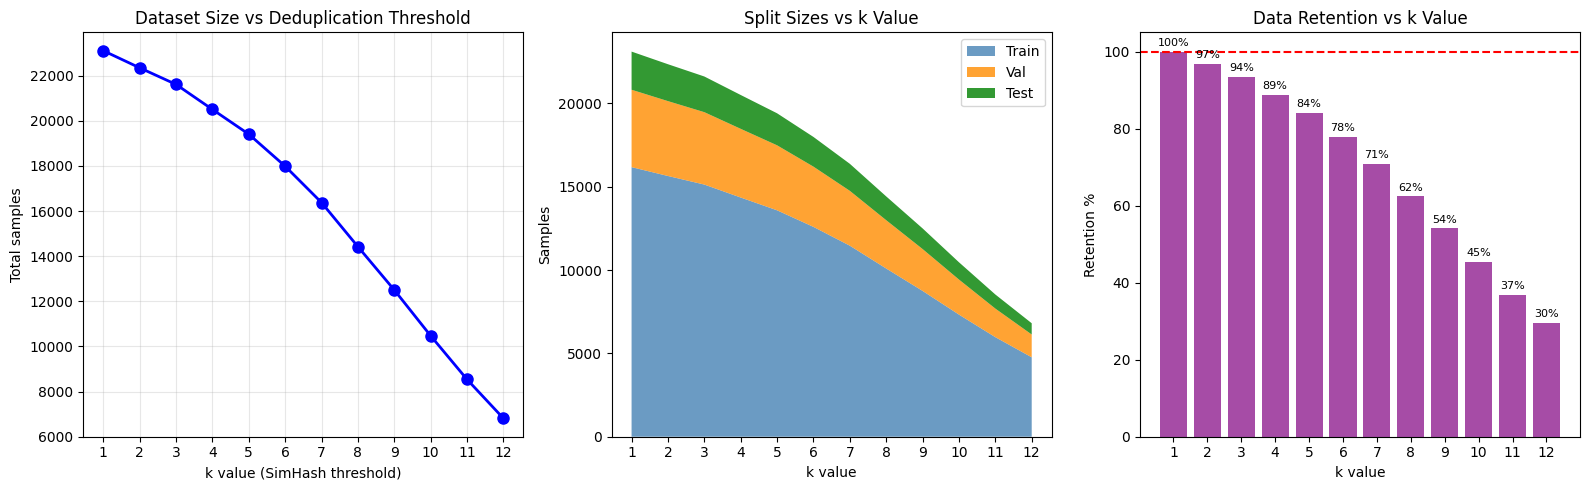


Plot saved to: /Users/aeg00011/Romeo/tensors/Experiment_4/dataset_sizes.png


In [18]:
# Visualize dataset sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total samples vs k
ax1 = axes[0]
ax1.plot(df_summary['k'], df_summary['total_samples'], 'o-', color='blue', linewidth=2, markersize=8)
ax1.set_xlabel('k value (SimHash threshold)')
ax1.set_ylabel('Total samples')
ax1.set_title('Dataset Size vs Deduplication Threshold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_summary['k'])

# Plot 2: Train/Val/Test sizes
ax2 = axes[1]
ax2.stackplot(df_summary['k'], 
              df_summary['train_size'], 
              df_summary['val_size'], 
              df_summary['test_size'],
              labels=['Train', 'Val', 'Test'],
              colors=['steelblue', 'darkorange', 'green'],
              alpha=0.8)
ax2.set_xlabel('k value')
ax2.set_ylabel('Samples')
ax2.set_title('Split Sizes vs k Value')
ax2.legend(loc='upper right')
ax2.set_xticks(df_summary['k'])

# Plot 3: Retention percentage
ax3 = axes[2]
bars = ax3.bar(df_summary['k'], df_summary['retention_pct'], color='purple', alpha=0.7)
ax3.axhline(y=100, color='r', linestyle='--', label='k=1 baseline')
ax3.set_xlabel('k value')
ax3.set_ylabel('Retention %')
ax3.set_title('Data Retention vs k Value')
ax3.set_xticks(df_summary['k'])
# Add percentage labels on bars
for bar, pct in zip(bars, df_summary['retention_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENT_DIR, 'dataset_sizes.png'), dpi=150)
plt.show()

print(f"\nPlot saved to: {os.path.join(EXPERIMENT_DIR, 'dataset_sizes.png')}")